# The Power of Prompting

Everything you built in this course so far had a fixed shape: a table goes in, a number comes out. Language models break that shape. They read and write **words**, and the words you send them, the **prompt**, decide almost everything about what comes back. Same model, same question, two different prompts: one answer is useless, the other is exactly what you needed.

This notebook makes that difference **measurable**. You will run a small language model on your own machine (no account, no API key), give it one real job from this course, and climb a ladder of prompts while a scoreboard tells you how much each rung is worth. Then comes the inspiring part: you will let the model **write its own prompts**, score them, and improve them in a loop. A program that improves its own instructions is one of the most useful ideas in applied AI today, and by the end you will have written one.

**What you will learn:**

- What a prompt really is, and why changing a few words changes the output (in-context learning)
- The prompt ladder: vague ask, specification, rules, role, examples. What each rung adds and why
- How to **measure** a prompt instead of arguing about it: a scored evaluation set, a dev/test split, the same honesty rule as in M2
- Self-generation prompting, four flavours: the model writes its own examples, checks its own work, writes the instruction, and optimizes the prompt in a loop (APE, Self-Refine, OPRO, and the idea behind DSPy)
- Where prompting stops and a bigger model, or fine-tuning, begins
- How this connects to the rest of the course: the extracted data feeds the exact survival model you deployed in M3

## How to run this notebook

- **Locally:** open it in Jupyter (`jupyter lab` or `jupyter notebook`) and run cells top to bottom.
- **Google Colab:** open it from GitHub and run cells top to bottom. A GPU makes the model faster (menu **Runtime > Change runtime type > T4 GPU**), but it is optional: everything works on a plain CPU, just slower.

The setup cell installs anything missing. The language model downloads once from Hugging Face and is cached: on a GPU or Apple silicon the notebook uses a 1.5-billion-parameter model (about 3 GB, the one whose numbers you see in this committed copy); on a plain CPU it switches to its 0.5-billion sibling (about 1 GB) so the run stays within a coffee break. Both behave the same way; the small one simply scores lower and its ladder is flatter. **No accounts and no API keys are needed.** One optional section near the end shows how the same code talks to a frontier model through an API; it is switched off by default and the notebook never stores a key.

Expect a total run time of a few minutes on a GPU and 20 to 30 minutes on a laptop CPU. The slow cells are marked.

In [1]:
# SETUP - run this cell first. It installs any missing packages.
# On Google Colab torch and transformers are already installed, so this usually does nothing.
import importlib.util, os, subprocess, sys

def ensure(package, pip_name=None):
    if importlib.util.find_spec(package) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name or package])

ensure("pandas"); ensure("numpy"); ensure("matplotlib"); ensure("sklearn", "scikit-learn")
ensure("torch"); ensure("transformers")

# Keep the output clean: no download progress bars, no library chatter.
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
import warnings; warnings.filterwarnings("ignore")
print("Setup complete.")

Setup complete.


# Part 1 - The theory

## 1. What a prompt really is

A language model is a program that was trained on an enormous amount of text to do one thing: **predict the next word**. Give it the beginning of a text and it continues it, one word (technically one *token*, a word piece) at a time, always choosing a likely continuation.

**In plain words:** autocomplete that has read a library. It has no goals, no memory of you, and no idea what you want. It only knows the text in front of it.

That text in front of it is the **prompt**. It is the only steering wheel you have at run time. You cannot open the model and change a setting for "be precise" or "answer in JSON". You can only write words, and the model continues them. This has one consequence that explains the whole notebook:

> **Everything you do not say, the model guesses.**

Concrete before abstract. Say *"extract the passenger data"* to a new colleague on their first day, and you get whatever they think passenger data is: maybe a sentence, maybe a table, maybe a question back. Say *"give me a JSON object with exactly these six fields, these allowed values, and nothing else"*, and you get a JSON object. The colleague did not become smarter between the two requests. Your request stopped leaving room for guesses.

### The three roles in a chat prompt

Modern models are trained on conversations, so a prompt is a list of messages, each with a role:

| Role | Who is speaking | What it is for |
|---|---|---|
| `system` | the operator (you, the developer) | who the model is, the standing rules, the output format. Set once |
| `user` | the person asking | the actual request, plus the text to work on |
| `assistant` | the model | its answers. You can also *write* assistant messages yourself, as examples of the answers you want |

The model never sees the roles as anything but text: a template glues them into one long string before predicting the next word. Roles are a convention the model learned, and it is a strong one, which is why the system message is the right place for rules.

## 2. Why words change the output: in-context learning

Here is the finding that made prompting a discipline. In 2020, the team that trained GPT-3 (Brown et al., *Language Models are Few-Shot Learners*) showed that a large model could learn a **new task from a handful of examples placed in the prompt**, with no training at all. Show it three translated sentences and it translates the fourth. Show it three labelled reviews and it labels the fourth. They called it **in-context learning**, and the number of examples in the prompt became a dial: zero-shot (no examples), one-shot, few-shot. Accuracy rose with every example added, on task after task.

**In plain words:** the model treats your prompt as a pattern and continues the pattern. If the pattern is "text, then a JSON object with six fields", the most likely continuation of a new text is a JSON object with six fields.

Under the hood nothing mysterious happens. The model computes a probability for every possible next token *given the whole prompt so far*:

$$P(\text{next token} \mid \text{prompt})$$

Change the prompt and you change that probability for every token that follows. A specification, a rule, an example: each one shifts probability away from the answers you do not want and towards the ones you do. Prompting is steering a probability distribution with words. That is also why it is not magic: if the model has never seen anything like your task, no prompt will make it good at it. The prompt can only unlock what training put in.

## 3. The prompt ladder

Good prompts are not clever; they are complete. Most of the gain comes from removing guesses, one kind at a time. The ladder below is the order in which professionals add things, and it is the order we will climb in Part 2. Each rung answers a question the model would otherwise have to guess.

| Rung | What you add | The guess it removes | Where the idea comes from |
|---|---|---|---|
| 0 | A vague ask | nothing: the baseline | |
| 1 | **Specification**: the task, the fields, the allowed values, the exact output format | *what* do you want and *in what shape* | plain requirements writing |
| 2 | **Rules**: your domain conventions and edge cases | how to handle the cases your data makes ambiguous | the model cannot know your conventions |
| 3 | **Role** in a system message: who the model is and what it never does | how to behave when the user text pulls it off course | instruction tuning and chat training |
| 4 | **Examples**: two to four input-output pairs, written as real conversation turns | what a perfect answer looks like, end to end | Brown et al. 2020, in-context learning |
| + | **Reasoning steps**: "think step by step before answering" | how to solve multi-step problems | Wei et al. 2022, chain-of-thought; Kojima et al. 2022, zero-shot CoT |

Two remarks on the last rung. Chain-of-thought is a real and large effect on arithmetic and logic puzzles with big models, and the famous version is only five words: *"Let's think step by step"* (Kojima et al. 2022). But it is not free: it makes outputs longer and, for small models on strict-format jobs like ours, it often *hurts*, because the model starts explaining instead of answering. We measure rather than assume, so it is an exercise at the end.

**In plain words, the ladder is:** say what you want, say how to handle the tricky cases, say who the model is, and show what good looks like. In that order, because that is roughly the order of return on effort. One caution on examples: a model *copies* its examples, so their choice, order and placement matter more than they seem (Zhao et al. 2021 measured how much few-shot results swing with them). Keep examples representative of the real inputs, and give them as real conversation turns rather than pasted text; Part 2 measures the difference.

## 4. Self-generation: prompts that write prompts

Now the idea this notebook is really about. A prompt is text. A language model writes text. So a language model can write prompts, including prompts for itself. Once you see that, prompting stops being a craft you do by hand and becomes something you can **program**:

1. **Generate** candidate prompts (by hand, or by asking a model).
2. **Score** each candidate on a set of examples with known answers.
3. **Keep** the best, and go back to step 1 with what you learned.

If that loop looks familiar, it should. It is exactly the shape of the hyperparameter search in M2 notebook 3: a search space, a scoring function, a loop that keeps the best. The prompt is just a hyperparameter made of words.

Four flavours of self-generation exist, each with a paper behind it, and each is a section in Part 2:

**a. The model writes its own examples.** Instead of you writing few-shot demonstrations, the model invents input-output pairs for the task and they are pasted into the prompt. Kim et al. 2022 called this *self-generated in-context learning*; Zhang et al. 2022 did the same for reasoning chains (*Auto-CoT*); Yasunaga et al. 2023 asked the model to first recall similar solved problems (*analogical prompting*). The lesson: the demonstrations matter more than who wrote them.

**b. The model checks its own work.** Draft, then criticize the draft, then revise: the same model, three prompts. Madaan et al. 2023 (*Self-Refine*) measured gains across tasks from dialogue to code with no extra training. It is the cheapest form of self-improvement and it maps onto how you already work: write, re-read, fix.

**c. The model writes the instruction.** Give the model a few input-output pairs and ask *"what instruction produced these?"*. Generate many candidate instructions, score each on held-out examples, keep the best. Zhou et al. 2022 called this the *Automatic Prompt Engineer* (APE). Their most quoted result: the search discovered *"Let's work this out in a step by step way to be sure we have the right answer"*, which beat the human-written *"Let's think step by step"* on arithmetic benchmarks (MultiArith 78.7 to 82.0, GSM8K 40.7 to 43.0, as reported in the paper).

**d. The optimizer loop.** Show the model the prompts tried so far *with their scores*, and ask for a better one. Repeat. Yang et al. 2023 (*Large Language Models as Optimizers*, OPRO) ran this loop and found *"Take a deep breath and work on this problem step-by-step"*, which scored 80.2% on GSM8K with PaLM 2-L against 71.8% for *"Let's think step by step"*. The model never saw the math; it only saw prompts and numbers, and it climbed.

**In plain words:** (a) the model writes the examples, (b) the model grades its own homework, (c) the model writes the instruction and you keep the best one, (d) the model reads the scoreboard and writes a better instruction. Each flavour trades a bit of your time for a bit of compute.

**What changed after 2023.** The newest optimizers stopped showing the author only *scores* and started showing it *traces*: the failed inputs, the wrong outputs, sometimes a line of human feedback. GEPA (Agrawal et al. 2025) evolves prompts by reflecting on such traces and reports large savings over reinforcement learning; TextGrad (Yuksekgonul et al. 2024) treats written critique as a gradient flowing back through a multi-step pipeline; ACE (Zhang et al. 2025) grows an evolving playbook from execution feedback alone. The common thread is the same loop as above, with a richer step 3: not "here is your score", but "here is what went wrong". We use that reflective step in section 9d, because it is the version that works with a small author.

### Where this is going

Put the four together with a scoring function and you get **prompt optimization as software**. Khattab et al. 2023 turned it into a library (*DSPy*, "programming, not prompting"): you declare what goes in, what comes out, and how to score it; an optimizer writes and selects the instructions and examples for you. Every large model provider now ships a "generate a prompt for me" button in its console. And a production pattern has emerged: **a big model writes, a small model runs**. You pay a frontier model once to design and tune the prompt, then run millions of cheap calls on a small model with that prompt. You will see exactly why that split makes sense in Part 2, when the small model does the extraction well but struggles to write its own instructions.

### The honesty rule (same as in M2)

When you choose a prompt because it scored best on ten examples, its score on those ten examples is no longer an honest estimate: you picked the winner *because* it did well on them. This is the selection-versus-assessment problem from M2 notebook 2, wearing new clothes. The fix is the same: **choose on a development set, report on a test set the choice never touched**. We will keep that discipline throughout, and you will see at least one case where the two numbers disagree.

### Limits, stated up front

- **Prompting unlocks, it does not add.** If the model never learned a skill, no prompt creates it. That is when you reach for a larger model or for fine-tuning.
- **Writing prompts needs a capable writer.** Our small model is a decent *worker* and a weak *author*. That is the point of the big-writes-small-runs pattern.
- **Small evaluation sets are noisy.** With ten test rows, one row is ten points. Treat differences of one row as noise, and make your set bigger before you make decisions that matter.
- **Specification beats cleverness.** Most real-world gains come from rung 1 to 3. Fancy techniques are the last few percent, not the first fifty.

# Part 2 - Practice

## 5. The job: from a sentence to the JSON our model needs

In M3 you deployed a survival model behind an API. That API accepts one passenger as a JSON object with fields like `Pclass`, `Sex`, `Age`, `SibSp`, `Parch` and `Embarked`. Real information rarely arrives that tidy. It arrives as **sentences**: a note, an email, a line in a report. Somebody has to turn *"Florence Cumings, 38, travelled first class with her husband; they embarked at Cherbourg"* into `{"Pclass": 1, "Sex": "female", "Age": 38, "SibSp": 1, "Parch": 0, "Embarked": "C"}`.

That translation is our job for the language model, and it is a good one for learning prompting for three reasons:

- **It has a right answer.** Every sentence below describes a real passenger from the course dataset, so we can score the model's JSON against the true row, field by field.
- **It has conventions the model cannot guess.** `SibSp` counts siblings *and* spouses; `Parch` counts parents *and* children; "steerage" means third class; the ports are letters, not names. Exactly the kind of thing a prompt must say.
- **It is the shape of most real LLM work in companies:** unstructured text in, structured data out, checked by a program.

**Six fields, six things to get right per passenger:**

| Field | Meaning | Allowed values |
|---|---|---|
| `Pclass` | ticket class | 1, 2, 3 |
| `Sex` | sex as recorded in 1912 | `"male"`, `"female"` |
| `Age` | age in years | a number |
| `SibSp` | siblings and spouses on board | a whole number |
| `Parch` | parents and children on board | a whole number |
| `Embarked` | port of boarding | `"S"` Southampton, `"C"` Cherbourg, `"Q"` Queenstown |

**What the next cell does / why:** it defines 24 passengers, each as a sentence plus the true values copied from the dataset, and splits them into three groups. The split is the honesty rule from Part 1 in code: 4 passengers we may *show* the model as examples, 10 we use to *choose* between prompts, and 10 we touch only at the very end to *report*.

In [2]:
PASSENGERS = [
    # demonstration pool: 4 passengers we may show the model as examples
    ('Owen Braund', 'Mr. Owen Harris Braund, a 22-year-old man in third class, boarded at Southampton with his brother.', dict(Pclass=3, Sex='male', Age=22, SibSp=1, Parch=0, Embarked='S')),
    ('Florence Cumings', 'Florence Cumings, 38, travelled first class with her husband John; they embarked at Cherbourg.', dict(Pclass=1, Sex='female', Age=38, SibSp=1, Parch=0, Embarked='C')),
    ('Frankie Goldsmith', 'Nine-year-old Frankie Goldsmith was in third class with his mother and father, having boarded at Southampton.', dict(Pclass=3, Sex='male', Age=9, SibSp=0, Parch=2, Embarked='S')),
    ('Patrick Dooley', 'Patrick Dooley, a 32-year-old third-class passenger, boarded alone at Queenstown.', dict(Pclass=3, Sex='male', Age=32, SibSp=0, Parch=0, Embarked='Q')),
    # development set: 10 passengers we use to compare and choose prompts
    ('Adele Nasser', 'Mrs. Adele Nasser was only 14 and travelling second class with her husband Nicholas from Cherbourg.', dict(Pclass=2, Sex='female', Age=14, SibSp=1, Parch=0, Embarked='C')),
    ('Marguerite Sandstrom', 'Four-year-old Marguerite Sandstrom sailed third class from Southampton with her mother and her sister.', dict(Pclass=3, Sex='female', Age=4, SibSp=1, Parch=1, Embarked='S')),
    ('Meier Moor', 'Six-year-old Meier Moor sailed in steerage from Southampton with his mother.', dict(Pclass=3, Sex='male', Age=6, SibSp=0, Parch=1, Embarked='S')),
    ('Mary Hewlett', 'Mrs. Mary Hewlett, aged 55, held a second-class ticket and boarded at Southampton on her own.', dict(Pclass=2, Sex='female', Age=55, SibSp=0, Parch=0, Embarked='S')),
    ('Bertram Dean', 'Bertram Dean was one year old, third class, travelling from Southampton with his parents and his sister.', dict(Pclass=3, Sex='male', Age=1, SibSp=1, Parch=2, Embarked='S')),
    ('Harriet Crosby', 'Miss Harriet Crosby, 36, first class, boarded at Southampton with her parents.', dict(Pclass=1, Sex='female', Age=36, SibSp=0, Parch=2, Embarked='S')),
    ('Helen Newsom', 'Miss Helen Newsom, 19, first class, boarded at Southampton with her mother and stepfather.', dict(Pclass=1, Sex='female', Age=19, SibSp=0, Parch=2, Embarked='S')),
    ('Harry Widener', 'Harry Widener, 27, travelled first class from Cherbourg accompanied by his father and mother.', dict(Pclass=1, Sex='male', Age=27, SibSp=0, Parch=2, Embarked='C')),
    ('Daisy Minahan', 'Daisy Minahan, aged 33, first class, boarded at Queenstown with her brother.', dict(Pclass=1, Sex='female', Age=33, SibSp=1, Parch=0, Embarked='Q')),
    ('Vera Dick', 'Mrs. Vera Dick, 17, first class, boarded at Southampton with her husband.', dict(Pclass=1, Sex='female', Age=17, SibSp=1, Parch=0, Embarked='S')),
    # test set: 10 passengers we only score at the very end, never to choose
    ('Vincenz Kink', 'Vincenz Kink, 26, third class, embarked at Southampton with his brother and sister.', dict(Pclass=3, Sex='male', Age=26, SibSp=2, Parch=0, Embarked='S')),
    ('Katriina Jussila', 'Katriina Jussila, a 20-year-old woman in third class, boarded at Southampton with her sister.', dict(Pclass=3, Sex='female', Age=20, SibSp=1, Parch=0, Embarked='S')),
    ('Eva Hart', 'Seven-year-old Eva Hart travelled second class from Southampton with her mother and father.', dict(Pclass=2, Sex='female', Age=7, SibSp=0, Parch=2, Embarked='S')),
    ('Michel Navratil', 'Three-year-old Michel Navratil travelled second class with his father and his younger brother, boarding at Southampton.', dict(Pclass=2, Sex='male', Age=3, SibSp=1, Parch=1, Embarked='S')),
    ('Nellie Barber', 'Nellie Barber, 26, a first-class passenger who boarded at Southampton by herself.', dict(Pclass=1, Sex='female', Age=26, SibSp=0, Parch=0, Embarked='S')),
    ('Washington Dodge', 'Four-year-old Washington Dodge sailed first class from Southampton with his parents.', dict(Pclass=1, Sex='male', Age=4, SibSp=0, Parch=2, Embarked='S')),
    ('Anna Lahtinen', 'Mrs. Anna Lahtinen, 26, in second class from Southampton with her husband and their daughter.', dict(Pclass=2, Sex='female', Age=26, SibSp=1, Parch=1, Embarked='S')),
    ('Madeleine Astor', 'Madeleine Astor, 18, first class, embarked at Cherbourg with her husband.', dict(Pclass=1, Sex='female', Age=18, SibSp=1, Parch=0, Embarked='C')),
    ('Eiriik Jussila', 'Eiriik Jussila, 32, steerage, boarded alone at Southampton.', dict(Pclass=3, Sex='male', Age=32, SibSp=0, Parch=0, Embarked='S')),
    ('Edward Crosby', 'Captain Edward Crosby, 70, first class, sailed from Southampton with his wife and daughter.', dict(Pclass=1, Sex='male', Age=70, SibSp=1, Parch=1, Embarked='S')),
]
DEMO, DEV, TEST = PASSENGERS[:4], PASSENGERS[4:14], PASSENGERS[14:24]

import pandas as pd
FIELDS = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Embarked"]

table = pd.DataFrame([{"group": g, "name": n, "text": t, **truth}
                      for g, rows in (("demo", DEMO), ("dev", DEV), ("test", TEST))
                      for n, t, truth in rows])
print(f"{len(PASSENGERS)} passengers: {len(DEMO)} demo, {len(DEV)} dev, {len(TEST)} test")
pd.set_option("display.max_colwidth", 90)
table.head(6)

24 passengers: 4 demo, 10 dev, 10 test


,group,name,text,Pclass,Sex,Age,SibSp,Parch,Embarked
0,demo,Owen Braund,"Mr. Owen Harris Braund, a 22-year-old man in third class, boarded at Southampton with ...",3,male,22,1,0,S
1,demo,Florence Cumings,"Florence Cumings, 38, travelled first class with her husband John; they embarked at Ch...",1,female,38,1,0,C
2,demo,Frankie Goldsmith,"Nine-year-old Frankie Goldsmith was in third class with his mother and father, having ...",3,male,9,0,2,S
3,demo,Patrick Dooley,"Patrick Dooley, a 32-year-old third-class passenger, boarded alone at Queenstown.",3,male,32,0,0,Q
4,dev,Adele Nasser,Mrs. Adele Nasser was only 14 and travelling second class with her husband Nicholas fr...,2,female,14,1,0,C
5,dev,Marguerite Sandstrom,Four-year-old Marguerite Sandstrom sailed third class from Southampton with her mother...,3,female,4,1,1,S


## 6. A small language model on your machine

We use **Qwen2.5-Instruct**, an open family of chat models trained to follow instructions in the system/user/assistant format from Part 1. The notebook picks the size for your machine: the **1.5-billion-parameter** model on a GPU or Apple silicon, the **0.5-billion** one on a plain CPU (frontier models have hundreds of times more parameters than either). You can force a size with the environment variable `FONTYS_MODEL` before starting Jupyter.

Small is a feature here. A frontier model would do this task almost perfectly with any reasonable prompt, and you would learn nothing. A small model is **sensitive to the prompt**, so the rungs of the ladder show up in the score. Everything you learn transfers upward: the same prompts work at least as well on bigger models. (With the 0.5B model expect lower numbers and a flatter ladder; the mechanics, and the lessons, are the same.)

**Two terms before the code:**

- **Tokenizer**: turns text into the integer tokens the model reads, and back. It also applies the **chat template**, the glue that turns a list of role-tagged messages into one string.
- **Greedy decoding**: at each step, take the single most likely next token. It makes the output *deterministic*: same prompt, same answer, every time. We use it for scoring. Later, when we want *variety* (several candidate prompts), we switch on **sampling**, which picks among likely tokens at random.

**What the next cell does / why:** it downloads the model once, picks the fastest device available (GPU, Apple silicon, or CPU) and builds one helper, `chat()`, that sends a list of messages and returns the model's reply as a string. A second helper, `chat_many()`, does the same for many conversations at once, which is several times faster on a CPU. This cell is the slow one on the first run (the download).

In [3]:
import time, torch
from transformers import AutoTokenizer, AutoModelForCausalLM

DEVICE = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
DEFAULT_MODEL = "Qwen/Qwen2.5-1.5B-Instruct" if DEVICE != "cpu" else "Qwen/Qwen2.5-0.5B-Instruct"
MODEL_ID = os.environ.get("FONTYS_MODEL", DEFAULT_MODEL)
torch.manual_seed(42)

t0 = time.time()
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.padding_side = "left"          # needed to generate for several prompts at once
model = AutoModelForCausalLM.from_pretrained(MODEL_ID).float().to(DEVICE).eval()
n_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"Loaded {MODEL_ID} ({n_params:,.0f}M parameters) on {DEVICE} in {time.time() - t0:.0f} s")


def chat_many(conversations, max_new_tokens=96, sample=False, batch_size=10):
    """Send many conversations (each a list of {'role', 'content'} messages). Returns the replies."""
    replies = []
    for i in range(0, len(conversations), batch_size):
        chunk = conversations[i:i + batch_size]
        texts = [tokenizer.apply_chat_template(c, tokenize=False, add_generation_prompt=True) for c in chunk]
        inputs = tokenizer(texts, return_tensors="pt", padding=True).to(DEVICE)
        with torch.no_grad():
            generated = model.generate(**inputs, max_new_tokens=max_new_tokens,
                                       do_sample=sample, temperature=0.8 if sample else None,
                                       top_p=0.95 if sample else None, pad_token_id=tokenizer.eos_token_id)
        new_tokens = generated[:, inputs["input_ids"].shape[1]:]   # keep only the reply
        replies += tokenizer.batch_decode(new_tokens, skip_special_tokens=True)
    return [r.strip() for r in replies]


def chat(messages, **kwargs):
    """One conversation in, one reply out."""
    return chat_many([messages], **kwargs)[0]


print(chat([{"role": "user", "content": "In one sentence: what was the Titanic?"}]))

Loaded Qwen/Qwen2.5-1.5B-Instruct (1,544M parameters) on mps in 8 s


The RMS Titanic was an ill-fated luxury ocean liner that sank in 1912 after hitting an iceberg during its maiden voyage from Southampton to New York City.


It talks. Now we need to make it work, and to make *work* measurable.

## 7. Scoring: how we measure a prompt

Arguing about prompts is a waste of time; scoring them is not. Our scorer is deliberately strict, because the API in M3 is strict: a value of `"Southampton"` where `"S"` is expected is a failed request, not a near miss. The scorer does three things:

1. **Finds the JSON** in the reply (the first `{...}` block) and parses it. No JSON, or broken JSON, means zero for that passenger.
2. **Normalizes only types and case**: `"Male"` counts as `"male"`, `22.0` counts as `22`. It never translates synonyms.
3. **Compares field by field** with the truth.

Three numbers come out, and each tells a different story:

| Metric | Question it answers |
|---|---|
| `valid_json` | did the model even answer in the right *shape*? |
| `field_accuracy` | of all fields across all passengers, what share is exactly right? (our headline number) |
| `perfect_rows` | what share of passengers is right in *all six* fields? (what the API would actually accept) |

**What the next cell does / why:** it defines the scorer and a small `show()` helper to print raw replies next to the truth, so you can always see *why* a prompt failed, not just that it did.

In [4]:
import json, re

def parse_json(text):
    """Return the first {...} object found in text as a dict, or None."""
    match = re.search(r"\{.*?\}", text, flags=re.S)
    if not match:
        return None
    try:
        obj = json.loads(match.group(0))
    except json.JSONDecodeError:
        return None
    return obj if isinstance(obj, dict) else None


def normalize(field, value):
    """Light normalization: types and case only, never synonyms."""
    try:
        if field in ("Pclass", "SibSp", "Parch"):
            return int(value)
        if field == "Age":
            return float(value)
        if field == "Sex":
            return str(value).strip().lower()
        if field == "Embarked":
            return str(value).strip().upper()
    except (TypeError, ValueError):
        return None


def score(replies, rows):
    """Compare the model's replies with the true values of the same rows."""
    n_valid = n_fields = n_perfect = 0
    for reply, (_, _, truth) in zip(replies, rows):
        obj = parse_json(reply)
        if obj is None:
            continue
        n_valid += 1
        correct = sum(normalize(f, obj.get(f)) == normalize(f, truth[f]) for f in FIELDS)
        n_fields += correct
        n_perfect += (correct == len(FIELDS))
    n = len(rows)
    return {"valid_json": n_valid / n,
            "field_accuracy": n_fields / (n * len(FIELDS)),
            "perfect_rows": n_perfect / n}


def per_field(replies, rows):
    """Accuracy of each field separately: which fields does a prompt fix, which stay broken?"""
    hits = {f: 0 for f in FIELDS}
    for reply, (_, _, truth) in zip(replies, rows):
        obj = parse_json(reply) or {}
        for f in FIELDS:
            hits[f] += normalize(f, obj.get(f)) == normalize(f, truth[f])
    return {f: hits[f] / len(rows) for f in FIELDS}


def show(replies, rows, n=2, width=160):
    """Print the first n replies next to the truth."""
    for reply, (name, _, truth) in list(zip(replies, rows))[:n]:
        print(f"{name}\n  truth: {json.dumps(truth)}\n  reply: {reply[:width]!r}\n")


def run(prompt_fn, rows, **kwargs):
    """Build one conversation per row with prompt_fn, ask the model, time it, return replies."""
    t0 = time.time()
    replies = chat_many([prompt_fn(text) for _, text, _ in rows], **kwargs)
    print(f"{len(rows)} passengers in {time.time() - t0:.0f} s")
    return replies

# A quick self-test of the scorer on a hand-written perfect reply and a broken one
perfect = json.dumps(DEV[0][2]); broken = "The passenger is a woman aged 14."
print(score([perfect, broken], DEV[:2]))

{'valid_json': 0.5, 'field_accuracy': 0.5, 'perfect_rows': 0.5}


## 8. Climbing the ladder

Five prompts for the same job, each one rung higher than the last (specification, then rules, then role, then examples). We score all five on the **dev set** (this is the *choosing* phase; the test set stays sealed). Read each prompt before you run it: the differences between them are the whole lesson.

**What the next cell does / why:** it writes the reusable pieces of text (the specification, the rules, the role) once, then defines five small functions that turn a passenger sentence into a conversation for the model. Notice how little changes from rung to rung: we only add, never rewrite.

In [5]:
SPEC = ("Extract these six fields and answer with one JSON object only, no other text: "
        "Pclass (1, 2 or 3), Sex (\"male\" or \"female\"), Age (a number), "
        "SibSp (number of siblings and spouses on board), Parch (number of parents and children on board), "
        "Embarked (\"S\" for Southampton, \"C\" for Cherbourg, \"Q\" for Queenstown).")

RULES = ("Rules: \"steerage\" means third class. \"alone\", \"on her own\" or \"by himself\" means SibSp 0 and Parch 0. "
         "A husband, wife, brother or sister counts in SibSp; a mother, father, son or daughter counts in Parch. "
         "\"Parents\" means Parch 2. Write ages as numbers.")

ROLE = "You are a careful data-entry assistant for a passenger database. You answer with one JSON object and nothing else."

def as_json(truth):
    return json.dumps(truth)

# Rung 0 - the vague ask
def prompt_vague(text):
    return [{"role": "user", "content": f"Extract the passenger data.\n\n{text}"}]

# Rung 1 - specification: fields, allowed values, output format
def prompt_spec(text):
    return [{"role": "user", "content": f"{SPEC}\n\nText: {text}"}]

# Rung 2 - rules: the conventions the model cannot know
def prompt_rules(text):
    return [{"role": "user", "content": f"{SPEC}\n{RULES}\n\nText: {text}"}]

# Rung 3 - role: the standing rules move into a system message that says who the model is
def prompt_role(text):
    return [{"role": "system", "content": f"{ROLE} {SPEC} {RULES}"},
            {"role": "user", "content": f"Text: {text}"}]

# Rung 4 - examples: two worked pairs (Owen and Florence), given as real conversation turns
def prompt_examples(text):
    messages = [{"role": "system", "content": f"{ROLE} {SPEC} {RULES}"}]
    for _, t, truth in DEMO[:2]:
        messages += [{"role": "user", "content": f"Text: {t}"}, {"role": "assistant", "content": as_json(truth)}]
    messages.append({"role": "user", "content": f"Text: {text}"})
    return messages

LADDER = {"0 vague ask": prompt_vague, "1 + specification": prompt_spec, "2 + rules": prompt_rules,
          "3 + role": prompt_role, "4 + examples": prompt_examples}

# Look at the two extremes for the same passenger before running anything
print(prompt_vague(DEV[0][1])[0]["content"])
print("\n" + "-" * 80 + "\n")
for m in prompt_examples(DEV[0][1]):
    print(f"[{m['role']}] {m['content']}\n")

Extract the passenger data.

Mrs. Adele Nasser was only 14 and travelling second class with her husband Nicholas from Cherbourg.

--------------------------------------------------------------------------------

[system] You are a careful data-entry assistant for a passenger database. You answer with one JSON object and nothing else. Extract these six fields and answer with one JSON object only, no other text: Pclass (1, 2 or 3), Sex ("male" or "female"), Age (a number), SibSp (number of siblings and spouses on board), Parch (number of parents and children on board), Embarked ("S" for Southampton, "C" for Cherbourg, "Q" for Queenstown). Rules: "steerage" means third class. "alone", "on her own" or "by himself" means SibSp 0 and Parch 0. A husband, wife, brother or sister counts in SibSp; a mother, father, son or daughter counts in Parch. "Parents" means Parch 2. Write ages as numbers.

[user] Text: Mr. Owen Harris Braund, a 22-year-old man in third class, boarded at Southampton with hi

**What the next cell does / why:** it runs all five rungs on the 10 dev passengers (50 model calls in total; about a minute on a GPU, several minutes on a CPU), scores each, and keeps the raw replies so we can inspect failures afterwards.

In [6]:
dev_replies, dev_scores = {}, {}
for rung, prompt_fn in LADDER.items():
    print(f"{rung:20s}", end="")
    dev_replies[rung] = run(prompt_fn, DEV)
    dev_scores[rung] = score(dev_replies[rung], DEV)

ladder_dev = pd.DataFrame(dev_scores).T
ladder_dev.round(2)

0 vague ask         

10 passengers in 6 s
1 + specification   

10 passengers in 4 s
2 + rules           

10 passengers in 4 s
3 + role            

10 passengers in 3 s
4 + examples        

10 passengers in 4 s


,valid_json,field_accuracy,perfect_rows
0 vague ask,0.0,0.00,0.0
1 + specification,1.0,0.90,0.4
2 + rules,1.0,0.87,0.4
3 + role,1.0,0.87,0.5
4 + examples,1.0,0.88,0.5


**What the next cell does / why:** numbers are one thing, seeing the replies is another. It prints what the model actually said at the bottom and at the top of the ladder for the same two passengers.

In [7]:
print("=== Rung 0, the vague ask ===\n")
show(dev_replies["0 vague ask"], DEV, n=2)
print("=== Rung 4, role + rules + examples ===\n")
show(dev_replies["4 + examples"], DEV, n=2)

=== Rung 0, the vague ask ===

Adele Nasser
  truth: {"Pclass": 2, "Sex": "female", "Age": 14, "SibSp": 1, "Parch": 0, "Embarked": "C"}
  reply: 'Passenger Data:\n\n- Name: Mrs. Adele Nasser\n- Age: 14 years old\n- Class: Second Class\n- Origin: Cherbourg'

Marguerite Sandstrom
  truth: {"Pclass": 3, "Sex": "female", "Age": 4, "SibSp": 1, "Parch": 1, "Embarked": "S"}
  reply: 'Passenger Data:\n\n- Name: Marguerite Sandstrom\n  - Age: Four years old\n  - Gender: Female\n  - Nationality: Not specified in the given text\n\n- Name: Mother (not e'

=== Rung 4, role + rules + examples ===

Adele Nasser
  truth: {"Pclass": 2, "Sex": "female", "Age": 14, "SibSp": 1, "Parch": 0, "Embarked": "C"}
  reply: '{"Pclass": 2, "Sex": "female", "Age": 14, "SibSp": 0, "Parch": 0, "Embarked": "C"}'

Marguerite Sandstrom
  truth: {"Pclass": 3, "Sex": "female", "Age": 4, "SibSp": 1, "Parch": 1, "Embarked": "S"}
  reply: '{"Pclass": 3, "Sex": "female", "Age": 4, "SibSp": 1, "Parch": 0, "Embarked": "S"}'



**What the next cell does / why:** it draws the ladder. One bar per rung, the headline metric (share of fields exactly right) in dark blue and the strict metric (share of passengers perfect in all six fields) in light blue.

**How to read it:** rungs go from the vague ask at the top to the full prompt at the bottom; longer bars are better; the gap between the two bars of a rung is the "almost right" zone, passengers with five correct fields and one wrong.

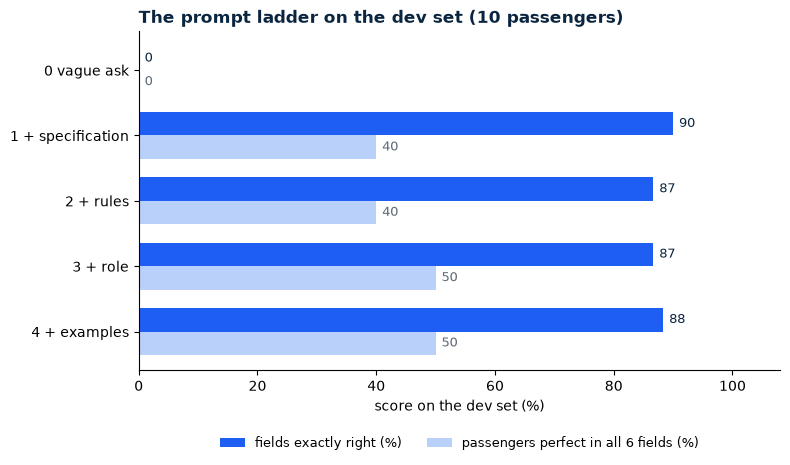

In [8]:
import matplotlib.pyplot as plt
import numpy as np

def plot_scores(df, title, filename, split="dev"):
    labels = list(df.index)
    y = np.arange(len(labels))
    fig, ax = plt.subplots(figsize=(8, 0.6 * len(labels) + 1.8))
    ax.barh(y - 0.18, df["field_accuracy"] * 100, height=0.36, color="#1E5EF3", label="fields exactly right (%)")
    ax.barh(y + 0.18, df["perfect_rows"] * 100, height=0.36, color="#B9D0FA", label="passengers perfect in all 6 fields (%)")
    for yi, (fa, pr) in enumerate(zip(df["field_accuracy"], df["perfect_rows"])):
        ax.text(fa * 100 + 1, yi - 0.18, f"{fa*100:.0f}", va="center", fontsize=9, color="#0A2540")
        ax.text(pr * 100 + 1, yi + 0.18, f"{pr*100:.0f}", va="center", fontsize=9, color="#5B6774")
    ax.set_yticks(y); ax.set_yticklabels(labels); ax.invert_yaxis()
    ax.set_xlim(0, 108); ax.set_xlabel(f"score on the {split} set (%)")
    ax.set_title(title, loc="left", fontweight="bold", color="#0A2540")
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=2, frameon=False, fontsize=9)
    fig.tight_layout()
    from pathlib import Path
    Path("outputs").mkdir(exist_ok=True)
    fig.savefig(f"outputs/{filename}", dpi=150)
    plt.show()

plot_scores(ladder_dev, "The prompt ladder on the dev set (10 passengers)", "ladder_dev.png")

**What the next cell does / why:** the headline number hides *which* fields improve. This table scores each field separately, per rung. Read it column by column: a column that reaches 1.0 is a field the prompt fixed; a column that stays low no matter the rung is the model's ceiling on this task.

In [9]:
fields_dev = pd.DataFrame({rung: per_field(replies, DEV) for rung, replies in dev_replies.items()}).T
fields_dev.round(2)

,Pclass,Sex,Age,SibSp,Parch,Embarked
0 vague ask,0.0,0.0,0.0,0.0,0.0,0.0
1 + specification,1.0,0.9,1.0,0.7,0.8,1.0
2 + rules,1.0,0.9,1.0,0.5,0.8,1.0
3 + role,1.0,0.9,1.0,0.6,0.7,1.0
4 + examples,1.0,0.9,1.0,0.7,0.7,1.0


### What just happened

- **Rung 0** rarely produces JSON at all: the model does what "extract" means to it, usually prose or a list. The task was not the problem; the missing shape was.
- **Rung 1** is the biggest single jump on most runs. Saying the fields, the allowed values and "JSON only" turns a chatty assistant into a data-entry clerk. This is the rung people skip, and it is the cheapest.
- **Rung 2** fixes the errors that no amount of intelligence could fix: "steerage", "alone", who counts in `SibSp` versus `Parch`. These are *your* conventions.
- **Rung 3** moves the same text into a system message with a one-line identity. The words barely change; what changes is where they sit, and chat models were trained to treat that position as the standing order.
- **Rung 4** shows the model what done looks like. Two details matter more than they seem: the examples are given as real user and assistant turns, not pasted into one message (in our runs the pasted version scored several points lower), and they are *representative* of the inputs. A model copies what it is shown.

- **The per-field table shows where the ceiling is.** Class, age and port are solved by rung 1 or 2. The weakest columns on every rung are the two family counts, `SibSp` and `Parch`: the model reads "with her mother and her sister" and has to decide which counter each relative belongs to, a two-step job for a small model. Rules and examples move these columns, but they do not reach the others. When no wording moves a column any more, you have found a skill the model lacks; that is the line between *prompting* and *needing a bigger model*, and section 10 is about crossing it.

The exact numbers will differ slightly between machines and model versions; the *shape* of the ladder is what repeats. And remember the size of our ruler: ten passengers, so one passenger is ten points of `perfect_rows`.

## 9. Self-generation: the model writes its own prompts

Everything above was written by a human. Now we hand the pen to the model, one flavour at a time, and keep scoring on the dev set. A reminder of the two roles the model plays from here on: the **worker** (extracts JSON from a sentence, greedy decoding, scored) and the **author** (writes examples, critiques, instructions; sampling on, so we get variety). Same model, two hats.

### 9a. The model writes its own examples

Rung 3 needed two worked examples that a human typed. Here the model invents them. We give it the task and *one* real pair from the demo pool and ask for two new passengers in the same format. Whatever it writes becomes the demonstrations in the prompt, wrong or right.

**What the next cell does / why:** it asks the author for two examples, prints them so you can judge them yourself, parses them into (text, JSON) pairs, builds a rung-4-style prompt around them (system message plus the invented pairs as conversation turns), and scores it on the dev set.

In [10]:
# The author's standing instruction. Without it a small model tends to *perform* the task it is asked to
# write about (it answers with JSON instead of writing an instruction). Learned the hard way; measured in 9c.
AUTHOR = {"role": "system", "content": ("You are a prompt engineer. You write instructions and examples for another "
                                        "language model. You never perform the task yourself; you only write the text "
                                        "that was asked for.")}

# Smaller loops when FONTYS_QUICK is set (used by the repository's CI, which runs on a slow CPU).
QUICK = bool(os.environ.get("FONTYS_QUICK"))
N_CANDIDATES = 3 if QUICK else 6
N_ROUNDS, N_PROPOSALS = (2, 1) if QUICK else (3, 3)


def author_examples(n=2):
    """Ask the model to invent n new (text, JSON) example pairs for our task."""
    seed_text, seed_truth = DEMO[0][1], DEMO[0][2]
    request = (f"The task for the other model is described between triple quotes:\n\"\"\"{SPEC}\n{RULES}\"\"\"\n\n"
               f"Here is one correct example:\nText: {seed_text}\nJSON: {as_json(seed_truth)}\n\n"
               f"Invent {n} new, different passengers (different class, sex, age, family and port). "
               f"For each one write one sentence in the same style and then its JSON. Use exactly this format:\n"
               f"Text: <sentence>\nJSON: <object>")
    reply = chat([AUTHOR, {"role": "user", "content": request}], max_new_tokens=320, sample=True)
    pairs = re.findall(r"Text:\s*(.+?)\s*\n\s*JSON:\s*(\{.*?\})", reply, flags=re.S)
    return reply, [(t.strip(), json.loads(j)) for t, j in pairs if parse_json(j)]

torch.manual_seed(42)
raw, self_examples = author_examples()
print(raw, "\n")
print(f"Parsed {len(self_examples)} usable example(s)")

def prompt_self_examples(text):
    messages = [{"role": "system", "content": f"{ROLE} {SPEC} {RULES}"}]
    for t, obj in self_examples[:2]:
        messages += [{"role": "user", "content": f"Text: {t}"}, {"role": "assistant", "content": json.dumps(obj)}]
    messages.append({"role": "user", "content": f"Text: {text}"})
    return messages

dev_replies["self-examples"] = run(prompt_self_examples, DEV)
dev_scores["self-examples"] = score(dev_replies["self-examples"], DEV)
print(dev_scores["self-examples"])

Text: Miss Emily Jane Jones, a 25-year-old woman in first class, was alone when she boarded at Cherbourg without any family on her journey.
JSON: {"Pclass": 1, "Sex": "female", "Age": 25, "SibSp": 0, "Parch": 0, "Embarked": "C"}

Text: Mr. Thomas Francis Williams, a 40-year-old man in second class, accompanied by his young child, boarded at Queenstown with his spouse and two daughters.
JSON: {"Pclass": 2, "Sex": "male", "Age": 40, "SibSp": 1, "Parch": 2, "Embarked": "Q"} 

Parsed 2 usable example(s)


10 passengers in 4 s
{'valid_json': 1.0, 'field_accuracy': 0.8666666666666667, 'perfect_rows': 0.4}


Look at the invented examples before you look at the score. Are the sentences plausible? Is the JSON consistent with the sentence? A small author often writes a sentence that says "with her husband" and a JSON with `SibSp: 0`. When the demonstrations are inconsistent, the worker learns the inconsistency. **The demonstrations matter more than who wrote them, and a weak author writes weak demonstrations.** Hold that thought for section 10.

### 9b. The model checks its own work

Self-Refine in three steps: draft, critique, revise. We take the drafts from rung 2 (specification and rules, no examples) and send each one back to the model with the original text and the instruction to verify every field and correct mistakes.

**What the next cell does / why:** one extra model call per passenger, then the same scorer. We keep the rung 2 drafts as the starting point on purpose: they contain real mistakes for the critic to find.

In [11]:
def refine(rows, drafts):
    """Second pass: show the model its own draft next to the text and ask it to verify and fix."""
    conversations = []
    for (_, text, _), draft in zip(rows, drafts):
        conversations.append([
            {"role": "system", "content": f"{ROLE} {SPEC} {RULES}"},
            {"role": "user", "content": (f"Text: {text}\n\nA first draft of the JSON is:\n{draft}\n\n"
                                         "Check every field against the text. If a field is wrong, correct it. "
                                         "Answer with the final JSON object only.")}])
    return chat_many(conversations)

t0 = time.time()
dev_replies["self-refine"] = refine(DEV, dev_replies["2 + rules"])
dev_scores["self-refine"] = score(dev_replies["self-refine"], DEV)
print(f"{len(DEV)} passengers refined in {time.time() - t0:.0f} s")
print("before (rung 2):", {k: round(v, 2) for k, v in dev_scores["2 + rules"].items()})
print("after  (refine):", {k: round(v, 2) for k, v in dev_scores["self-refine"].items()})
show(dev_replies["self-refine"], DEV, n=2)

10 passengers refined in 4 s
before (rung 2): {'valid_json': 1.0, 'field_accuracy': 0.87, 'perfect_rows': 0.4}
after  (refine): {'valid_json': 1.0, 'field_accuracy': 0.85, 'perfect_rows': 0.3}
Adele Nasser
  truth: {"Pclass": 2, "Sex": "female", "Age": 14, "SibSp": 1, "Parch": 0, "Embarked": "C"}
  reply: '```json\n{\n  "Pclass": 2,\n  "Sex": "female",\n  "Age": 14,\n  "SibSp": 0,\n  "Parch": 0,\n  "Embarked": "C"\n}\n```'

Marguerite Sandstrom
  truth: {"Pclass": 3, "Sex": "female", "Age": 4, "SibSp": 1, "Parch": 1, "Embarked": "S"}
  reply: '```json\n{\n  "Pclass": 3,\n  "Sex": "female",\n  "Age": 4.0,\n  "SibSp": 0,\n  "Parch": 1,\n  "Embarked": "S"\n}\n```'



Self-critique helps when the model *knows* the answer but did not *say* it carefully the first time (format slips, a missed field). It cannot help when the model does not know the convention: a critic who thinks "steerage" is second class will confidently confirm the wrong class, and it can even talk a correct draft into a wrong one, which is what a small drop after refining means. Cheap, sometimes useful, and no substitute for rules.

### 9c. The model writes the instruction (APE)

Now the real trick. We do not tell the model what the task is. We show it the four demo pairs and ask: *"what instruction produced these outputs?"*. Because sampling is on, every call gives a different instruction. We generate several, score every one on the dev set, and keep the best. This is the Automatic Prompt Engineer recipe (Zhou et al. 2022): **propose, score, select**.

**What the next cell does / why:** it builds the meta-prompt from the demo pairs, samples six candidate instructions, wraps each one into a rung-1-style prompt (instruction, then the text), scores all six on the dev set, and prints a leaderboard. Six candidates times ten passengers is 60 calls, plus the six author calls.

In [12]:
def induce_instructions(n=6):
    """APE step 1: from input-output pairs, ask the model to write the instruction that produced them."""
    pairs = "\n\n".join(f"Input: {t}\nOutput: {as_json(truth)}" for _, t, truth in DEMO)
    meta = (f"A colleague received an instruction and applied it to these inputs, producing these outputs.\n\n{pairs}\n\n"
            "Write the instruction they received. Be specific about the fields, the allowed values and the output "
            "format. Answer with the instruction only.")
    return chat_many([[AUTHOR, {"role": "user", "content": meta}]] * n, max_new_tokens=220, sample=True)

def prompt_with(instruction):
    """Turn any instruction string into a prompt function for the worker."""
    def prompt_fn(text):
        return [{"role": "user", "content": f"{instruction}\n\nText: {text}\nJSON:"}]
    return prompt_fn

torch.manual_seed(42)
t0 = time.time()
candidates = induce_instructions(N_CANDIDATES)
print(f"{N_CANDIDATES} candidate instructions written in {time.time() - t0:.0f} s\n")

ape_board = []
for i, instruction in enumerate(candidates):
    replies = run(prompt_with(instruction), DEV)
    s = score(replies, DEV)
    ape_board.append({"candidate": i, "field_accuracy": s["field_accuracy"], "perfect_rows": s["perfect_rows"],
                      "valid_json": s["valid_json"], "instruction": instruction})

ape_df = pd.DataFrame(ape_board).sort_values("field_accuracy", ascending=False).reset_index(drop=True)
best_ape = ape_df.loc[0, "instruction"]
pd.set_option("display.max_colwidth", 70)
ape_df

6 candidate instructions written in 9 s



10 passengers in 5 s


10 passengers in 4 s


10 passengers in 4 s


10 passengers in 3 s


10 passengers in 6 s


10 passengers in 5 s


,candidate,field_accuracy,perfect_rows,valid_json,instruction
0,1,0.850000,0.1,1.0,"The instruction provided was:\n\n""Take each input name and age alo..."
1,2,0.783333,0.2,1.0,"The input data consists of a name, age, ticket status (first or th..."
2,0,0.333333,0.0,1.0,"Your colleague received the following instruction:\n\n""Given a per..."
3,3,0.166667,0.0,1.0,The instruction your colleague received is as follows:\n\nGiven th...
4,4,0.150000,0.0,0.5,The instruction is as follows:\n\nGiven input data representing in...
5,5,0.033333,0.0,0.2,The instruction is as follows:\n\nGiven a passenger's details incl...


In [13]:
print("Best self-written instruction (dev field accuracy "
      f"{ape_df.loc[0, 'field_accuracy']:.0%}):\n\n{best_ape}\n")
print("Worst candidate (dev field accuracy "
      f"{ape_df['field_accuracy'].iloc[-1]:.0%}):\n\n{ape_df['instruction'].iloc[-1]}")

dev_replies["APE best"] = run(prompt_with(best_ape), DEV)
dev_scores["APE best"] = score(dev_replies["APE best"], DEV)

Best self-written instruction (dev field accuracy 85%):

The instruction provided was:

"Take each input name and age along with their respective class, gender, number of siblings/spouses aboard (SibSp), number of parents/children aboard (Parch), and port of embarkation (Embarked). Format them into a JSON object as shown below."

Here is how this output format should look:

```json
{"Pclass": <class>, "Sex": "<gender>", "Age": <age>, "SibSp": <sibsp>, "Parch": < parch>, "Embarked": "<embarked>"}
```

The allowed values are:
- Pclass: Can be 1, 2 or 3
- Sex: Can be either "male" or "female"
- Age: Must be an integer between 0 and 100 inclusive
- SibSp: Must be an integer between 0 and 6 inclusive
- Parch: Must be an integer between 0 and 6 inclusive
- Embarked: Can be "C", "Q", or "S"

Inputs were

Worst candidate (dev field accuracy 3%):

The instruction is as follows:

Given a passenger's details including age, gender, family status (sibsp/sp, parch), ticket class (pclass), embarkatio

10 passengers in 4 s


Two things to notice on the leaderboard. First, the **spread**: the same author, the same meta-prompt, and candidates that differ by tens of points. Sampling gives variety, and variety is what selection needs. Second, compare the best candidate with your hand-written rung 1 and rung 2: a small author usually forgets some allowed values or the port codes, exactly the parts a human requirements writer would nail. Selection can only pick the best of what was proposed.

### 9d. The optimizer loop (OPRO, with a reflection step)

APE proposes blindly. The optimizer loop proposes *with feedback*. OPRO (Yang et al. 2023) showed the author the instructions tried so far with their scores and asked for a better one. Newer optimizers such as GEPA (2025) add the step that makes small authors useful: show the author the **actual failures** of the current best instruction and ask for a targeted edit, *keep what works, add the rule that fixes what does not*. Keep the best, repeat. We run that reflective version, shrunk to three rounds and three proposals per round. (We tried the pure scoreboard version first: with an author this small it mostly proposed unrelated instructions and the curve stayed flat. Measured, not assumed.)

**What the next cell does / why:** it seeds the history with the rung 1 specification and the best APE candidate, then runs three rounds: take the best instruction so far, collect three passengers it gets wrong, ask the author for three improved instructions, score them on the dev set, add them to the history. It records the best score after every round so we can draw the climb.

In [14]:
def failures_of(replies, rows, k=3):
    """Short descriptions of up to k passengers where the reply was not perfect."""
    lines = []
    for reply, (name, text, truth) in zip(replies, rows):
        obj = parse_json(reply) or {}
        wrong = [f for f in FIELDS if normalize(f, obj.get(f)) != normalize(f, truth[f])]
        if wrong:
            lines.append(f"- Text: {text}\n  Expected: {as_json(truth)}\n  Got: {reply[:120]!r}")
        if len(lines) == k:
            break
    return "\n".join(lines)

def propose(best_instruction, failures, n=2):
    """Reflection step: show the best instruction and its failures, ask for a targeted improvement."""
    meta = ("Below is the best instruction so far for a data-extraction task, between triple quotes, followed by "
            f"inputs it still gets wrong.\n\n\"\"\"{best_instruction}\"\"\"\n\nFailures:\n{failures}\n\n"
            "Write an improved version of the instruction: keep everything that already works, and add or sharpen "
            "the rules needed to fix these failures. Do not perform the extraction yourself. "
            "Answer with the text of the new instruction only.")
    return chat_many([[AUTHOR, {"role": "user", "content": meta}]] * n, max_new_tokens=300, sample=True)

torch.manual_seed(42)
spec_replies = run(prompt_with(SPEC), DEV)
history = [{"round": 0, "instruction": SPEC, "score": score(spec_replies, DEV)["field_accuracy"], "replies": spec_replies},
           {"round": 0, "instruction": best_ape, "score": float(ape_df.loc[0, "field_accuracy"]), "replies": dev_replies["APE best"]}]
best_so_far = [max(h["score"] for h in history)]

for rnd in range(1, N_ROUNDS + 1):
    best = max(history, key=lambda h: h["score"])
    fails = failures_of(best["replies"], DEV)
    for instruction in propose(best["instruction"], fails, n=N_PROPOSALS):
        instruction = instruction.strip().strip('"').strip()          # authors sometimes echo the quotes back
        replies = run(prompt_with(instruction), DEV)
        history.append({"round": rnd, "instruction": instruction, "score": score(replies, DEV)["field_accuracy"], "replies": replies})
    best_so_far.append(max(h["score"] for h in history))
    print(f"round {rnd}: best so far {best_so_far[-1]:.0%}")

opro_df = pd.DataFrame(history).drop(columns="replies")
winner = max(history, key=lambda h: h["score"])
best_opro, dev_replies["OPRO best"] = winner["instruction"], winner["replies"]
dev_scores["OPRO best"] = score(dev_replies["OPRO best"], DEV)
opro_df[["round", "score", "instruction"]]

10 passengers in 3 s


10 passengers in 4 s


10 passengers in 5 s


10 passengers in 4 s
round 1: best so far 90%


10 passengers in 5 s


...

10 passengers in 7 s
round 2: best so far 90%


10 passengers in 6 s


10 passengers in 9 s


10 passengers in 6 s
round 3: best so far 92%


,round,score,instruction
0,0,0.883333,"Extract these six fields and answer with one JSON object only, no ..."
1,0,0.850000,"The instruction provided was:\n\n""Take each input name and age alo..."
2,1,0.883333,"Extract these six fields and answer with one JSON object only, no ..."
3,1,0.900000,Extract the following fields for each passenger and respond with a...
4,1,0.850000,Extract the following six fields for each passenger record and for...
5,2,0.900000,Extract the following fields for each passenger and respond with a...
6,2,0.850000,Extract the following fields for each passenger and respond with a...
7,2,0.833333,Extract the following fields for each passenger and respond with a...
8,3,0.916667,Extract the following fields for each passenger and respond with a...
9,3,0.766667,Extract the following fields for each passenger and respond with a...


**What the next cell does / why:** it draws the best dev score after each round of the optimizer, next to the two seeds it started from.

**How to read it:** the x-axis is the round (0 is the starting point, the better of the two seeds); the line can only go up or stay flat because we always keep the best; a flat round means no proposal beat the incumbent.

Two honest readings, depending on your run. If the line climbed, the author turned failures into a rule the human had not written, and you watched search beat hand-writing. If it stayed flat, the incumbent (usually the human specification) was already at this author's ceiling: nine proposals from a 1.5B model, scored on ten passengers, is a small search. More proposals, a larger dev set and, above all, a stronger author are the three dials; section 10 turns the third one.

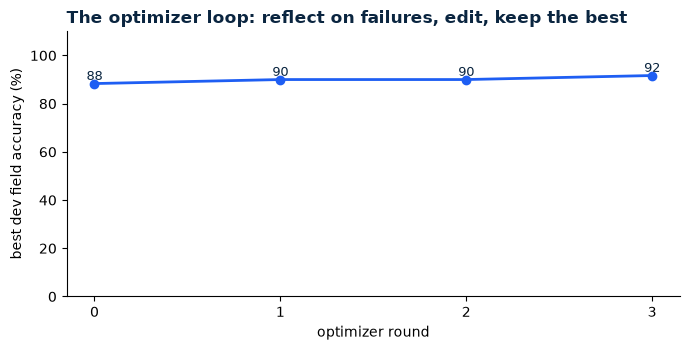

After 3 rounds the best dev score climbed from 88% to 92%.

Best instruction in the history:

Extract the following fields for each passenger and respond with a single JSON object without any additional text:

- Pclass (integer value representing class, either 1, 2, or 3)
- Sex (string indicating gender, either "male" or "female")
- Age (float value representing age as a number)
- SibSp (integer value representing number of siblings/spouses aboard)
- Parch (integer value representing number of parents/children aboard)
- Embarked (string indicating port of embarkation, either "S" for Southampton, "C" for Cherbourg, or "Q" for Queenstown)

For each failure example provided, ensure the extracted values match the expected output exactly.

Examples:
- For "Mrs. Adele Nasser":
  Expected Output: {"Pclass": 2, "Sex": "female", "Age": 14, "SibSp": 1, "Parch": 0, "Embarked": "C"}
  Actual Output: ```json \{ "Pclass": 2, "Sex": "female", "Age": 14, "SibSp": 1, "Parch": 0, "Embarked": "C" \}```
-

In [15]:
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(range(len(best_so_far)), [b * 100 for b in best_so_far], marker="o", color="#1E5EF3", lw=2)
for x, b in enumerate(best_so_far):
    ax.text(x, b * 100 + 1.5, f"{b*100:.0f}", ha="center", fontsize=9, color="#0A2540")
ax.set_xticks(range(len(best_so_far))); ax.set_xlabel("optimizer round")
ax.set_ylabel("best dev field accuracy (%)"); ax.set_ylim(0, 110)
ax.set_title("The optimizer loop: reflect on failures, edit, keep the best", loc="left", fontweight="bold", color="#0A2540")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout(); fig.savefig("outputs/opro_curve.png", dpi=150); plt.show()

start, end = best_so_far[0], best_so_far[-1]
verdict = (f"climbed from {start:.0%} to {end:.0%}" if end > start + 1e-9
           else f"stayed flat at {start:.0%}: none of the {N_ROUNDS * N_PROPOSALS} proposals beat the incumbent")
print(f"After {N_ROUNDS} rounds the best dev score {verdict}.\n")
print("Best instruction in the history:\n")
print(best_opro)

### 9e. The honest scoreboard: everything on the test set

Every number so far was measured on the dev set, and we used those numbers to *choose*: the best APE candidate, the best optimizer round. Their dev scores are flattered by that choice. Now we unseal the ten test passengers and score every approach once, with no more choosing afterwards. This is the number you would report.

**What the next cell does / why:** it runs each prompt on the test set (the ladder, the three self-generation flavours and the optimizer's winner; self-refine is applied to the rung 2 test drafts), then draws the same chart as before, this time on test.

In [16]:
test_prompts = dict(LADDER)
test_prompts.update({"self-examples": prompt_self_examples, "APE best": prompt_with(best_ape), "OPRO best": prompt_with(best_opro)})

test_replies, test_scores = {}, {}
for name, prompt_fn in test_prompts.items():
    print(f"{name:20s}", end="")
    test_replies[name] = run(prompt_fn, TEST)
    test_scores[name] = score(test_replies[name], TEST)
print(f"{'self-refine':20s}", end="")
t0 = time.time(); test_replies["self-refine"] = refine(TEST, test_replies["2 + rules"]); print(f"{len(TEST)} passengers in {time.time() - t0:.0f} s")
test_scores["self-refine"] = score(test_replies["self-refine"], TEST)

order = list(LADDER) + ["self-examples", "self-refine", "APE best", "OPRO best"]
scoreboard = pd.DataFrame({"dev": {k: dev_scores[k]["field_accuracy"] for k in order},
                           "test": {k: test_scores[k]["field_accuracy"] for k in order}})
scoreboard["gap"] = scoreboard["test"] - scoreboard["dev"]
scoreboard.round(2)

0 vague ask         

10 passengers in 4 s
1 + specification   

10 passengers in 5 s
2 + rules           

10 passengers in 6 s
3 + role            

10 passengers in 6 s
4 + examples        

...

10 passengers in 7 s
APE best            

10 passengers in 8 s
OPRO best           

10 passengers in 11 s
self-refine         

10 passengers in 9 s


,dev,test,gap
0 vague ask,0.00,0.00,0.00
1 + specification,0.90,0.82,-0.08
2 + rules,0.87,0.90,0.03
3 + role,0.87,0.92,0.05
4 + examples,0.88,0.92,0.03
self-examples,0.87,0.90,0.03
self-refine,0.85,0.90,0.05
APE best,0.85,0.90,0.05
OPRO best,0.92,0.85,-0.07


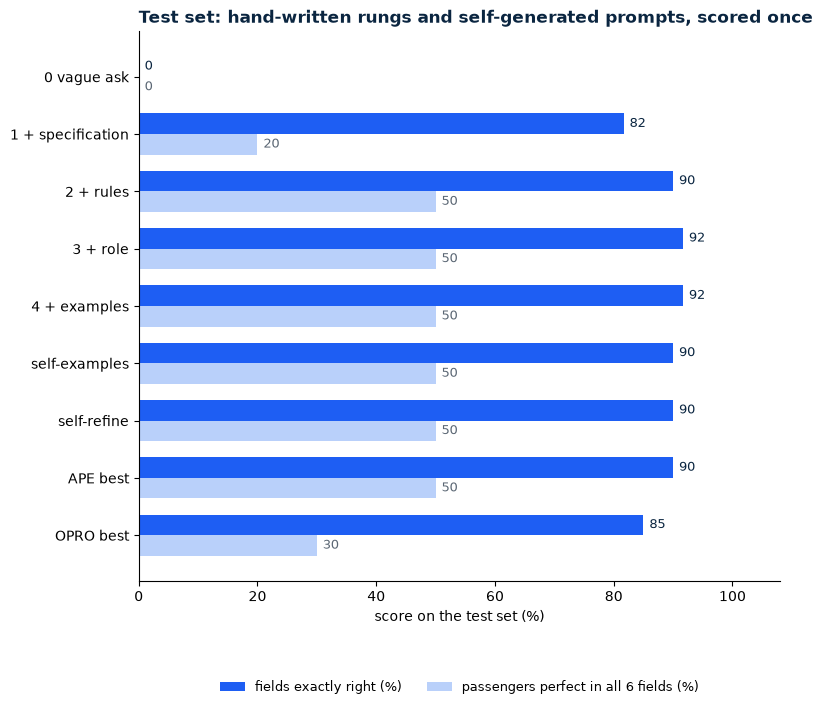

In [17]:
test_df = pd.DataFrame(test_scores).T.loc[order]
plot_scores(test_df, "Test set: hand-written rungs and self-generated prompts, scored once", "scoreboard_test.png", split="test")

import json as _json
from pathlib import Path
Path("outputs").mkdir(exist_ok=True)
_json.dump({"dev": dev_scores, "test": test_scores, "best_ape": best_ape, "best_opro": best_opro,
            "opro_best_so_far": best_so_far, "model": MODEL_ID, "device": DEVICE,
            "fields_dev": {k: per_field(v, DEV) for k, v in dev_replies.items()},
            "fields_test": {k: per_field(v, TEST) for k, v in test_replies.items()},
            "ape_board": ape_df[["candidate", "field_accuracy", "perfect_rows", "valid_json"]].to_dict("records"),
            "opro_history": opro_df[["round", "score"]].to_dict("records")},
           open("outputs/m4_results.json", "w"), indent=2)

### Reading the scoreboard

- **The `gap` column is the honesty rule in numbers.** Prompts that were *chosen* on dev (APE best, OPRO best) tend to lose points on test; hand-written rungs, chosen by no score, move less. With ten rows a gap of one row (about 2 points of field accuracy, 10 of perfect rows) is noise, so only read the large gaps.
- **Look at the optimizer's winning instruction again.** If it quotes dev passengers together with their correct JSON, the author did not write a better rule: it copied part of the answer key into the prompt. That instruction scores well on dev *because* the answers are in it, and the test set, which it never saw, takes the points back. This is overfitting made literal, and the reason the test set exists.
- **Specification and rules did most of the work.** On a small model they are usually worth more than any self-generation trick, because the small author cannot write what it does not know.
- **Self-generation still earned its keep in one way:** it produced, without a human writing a single rule, an instruction in the same league as the human rung 1 or 2, and it found it by *search*. Give the same loop a better author, more candidates and a bigger dev set, and it stops being a demo. That is the next section.

## 10. Optional: a frontier model writes the prompt, the small model runs it

Section 9 showed the weak link: our small model is a fair worker and a poor author. In industry the fix is a division of labour called **big writes, small runs**. You pay a frontier model a few cents, once, to read the task, the examples and the failures and write a precise instruction. Then the small, cheap model runs that instruction millions of times. The prompt is designed by the best author you can afford and executed by the cheapest worker that scores well enough.

This section is **switched off by default** because it needs an API key, and this course never stores keys (see M3 notebook 3 on where keys live). If you have an Anthropic key, set `USE_CLAUDE = True` and the cell asks for the key at run time with a hidden input; it is kept in memory only and never written to the notebook or to disk. Without a key, read the code: it is the same recipe as 9c and 9d with a different author.

**What the next cell does / why:** if enabled, it defines a `claude()` helper (same message format as `chat()`), asks the frontier model to write an instruction for our small worker using the demo pairs and the rung-2 failures, and scores that instruction with the *small* model on dev and test. The frontier model never extracts a single passenger itself; it only writes.

In [18]:
USE_CLAUDE = False   # set to True to run this section with your own Anthropic API key

if USE_CLAUDE:
    ensure("anthropic")
    import anthropic
    from getpass import getpass
    if "ANTHROPIC_API_KEY" not in os.environ:
        os.environ["ANTHROPIC_API_KEY"] = getpass("Anthropic API key (hidden, kept in memory only): ")
    client = anthropic.Anthropic()

    def claude(messages, system="You are an expert prompt engineer.", max_tokens=2048):
        response = client.messages.create(model="claude-opus-5", max_tokens=max_tokens,
                                          system=system, messages=messages)
        if response.stop_reason == "refusal":
            return ""
        return "".join(block.text for block in response.content if block.type == "text").strip()

    pairs = "\n\n".join(f"Input: {t}\nOutput: {as_json(truth)}" for _, t, truth in DEMO)
    fails = failures_of(dev_replies["2 + rules"], DEV, k=4)
    brief = (f"A small 0.5B-parameter language model must turn one sentence about a Titanic passenger into a JSON "
             f"object with the fields {FIELDS}. It will receive your instruction followed by 'Text: <sentence>' "
             f"and 'JSON:'. Write the instruction. Keep it under 150 words, name every allowed value, and include "
             f"rules for the ambiguous cases you see below. Answer with the instruction only.\n\n"
             f"Examples of correct behaviour:\n{pairs}\n\nMistakes the small model made with a weaker instruction:\n{fails}")
    frontier_instruction = claude([{"role": "user", "content": brief}])
    print(frontier_instruction, "\n")

    dev_scores["frontier-written"] = score(run(prompt_with(frontier_instruction), DEV), DEV)
    test_scores["frontier-written"] = score(run(prompt_with(frontier_instruction), TEST), TEST)
    print("dev :", {k: round(v, 2) for k, v in dev_scores["frontier-written"].items()})
    print("test:", {k: round(v, 2) for k, v in test_scores["frontier-written"].items()})
else:
    print("Skipped. Set USE_CLAUDE = True (and have an API key ready) to let a frontier model write the instruction.")

Skipped. Set USE_CLAUDE = True (and have an API key ready) to let a frontier model write the instruction.


Whether or not you ran it, the pattern is the lesson: **the author and the worker do not have to be the same model.** Pick the author for quality and the worker for cost. Every prompt-optimization library (DSPy and its successors) is built on this split, with a scorer like ours in the middle.

## 11. From words to a prediction: closing the loop with M3

One last cell to connect this notebook to the rest of the course. The JSON we extract has exactly the shape the survival model from M2 and M3 expects. So: sentence in, prompt, JSON out, model, survival probability. The whole course in one pipeline.

**What the next cell does / why:** it trains the course's survival model with the canonical M2 preparation (compact version, fully explained in M2 notebook 1 and M3 notebook 2), takes one *test* passenger, extracts her data with our best hand-written prompt, fills the two fields the sentence does not contain (`Fare`, from the class median, and `Title`, from the name), and asks the model for her probability of surviving.

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic = pd.read_csv(url)
titanic["Title"] = titanic["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
titanic["Title"] = titanic["Title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
titanic.loc[~titanic["Title"].isin(["Mr", "Mrs", "Miss", "Master"]), "Title"] = "Rare"
titanic["FamilySize"] = titanic["SibSp"] + titanic["Parch"] + 1
titanic["IsAlone"] = (titanic["FamilySize"] == 1).astype(int)
numeric = ["Age", "Fare", "SibSp", "Parch", "FamilySize"]
categorical = ["Pclass", "Sex", "Embarked", "Title"]
prep = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), numeric),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                      ("encode", OneHotEncoder(handle_unknown="ignore"))]), categorical)])
survival_model = Pipeline([("prep", prep), ("lr", LogisticRegression(max_iter=1000, random_state=42))])
survival_model.fit(titanic[numeric + categorical], titanic["Survived"])

# One sentence from the test set, through our best hand-written prompt
name, sentence, truth = TEST[7]           # Madeleine Astor
extracted = parse_json(chat(prompt_examples(sentence)))
print(f"Sentence : {sentence}\nExtracted: {extracted}\nTruth    : {truth}\n")

row = dict(extracted)
row["Fare"] = titanic.loc[titanic["Pclass"] == int(row["Pclass"]), "Fare"].median()   # not in the sentence
row["Title"] = "Mrs" if "Mrs." in sentence or "husband" in sentence else ("Miss" if row["Sex"] == "female" else "Mr")
row["FamilySize"] = int(row["SibSp"]) + int(row["Parch"]) + 1
probability = survival_model.predict_proba(pd.DataFrame([row])[numeric + categorical])[0, 1]
print(f"{name}: predicted probability of survival {probability:.0%}  "
      f"(she did {'survive' if titanic.loc[titanic['Name'].str.contains('Astor'), 'Survived'].iloc[0] else 'not survive'})")

Sentence : Madeleine Astor, 18, first class, embarked at Cherbourg with her husband.
Extracted: {'Pclass': 1, 'Sex': 'female', 'Age': 18, 'SibSp': 0, 'Parch': 0, 'Embarked': 'C'}
Truth    : {'Pclass': 1, 'Sex': 'female', 'Age': 18, 'SibSp': 1, 'Parch': 0, 'Embarked': 'C'}

Madeleine Astor: predicted probability of survival 98%  (she did survive)


Text went in, a probability came out, and no human typed a number in between. Compare the extracted line with the truth above: if a field is off, that is the error budget of section 8 travelling downstream into the prediction, which is exactly why the scorer exists. That is what prompting is *for* in a data system: the bridge between how information arrives and how models consume it, with a measurement in the middle.

## Key takeaways

- A language model continues text. The prompt is the only steering wheel, so **everything you do not say, the model guesses**.
- **In-context learning** (Brown et al. 2020) is why words work: the prompt shifts the probability of every token that follows. Specification, rules and examples each remove a kind of guess.
- The **ladder**: say what you want (fields, values, format), say how to handle the tricky cases, show what good looks like, say who the model is. Most of the gain is in the first two rungs.
- **Measure, do not argue.** A scored evaluation set turns prompting into engineering. Three numbers told three stories: shape (`valid_json`), quality (`field_accuracy`), usability (`perfect_rows`).
- **Choose on dev, report on test.** Selecting a prompt by its score makes that score optimistic. Same rule as model selection in M2.
- **Self-generation** comes in four flavours: the model writes examples, checks its own work, writes the instruction (APE: propose, score, select), or optimizes it with feedback (OPRO and its reflective successors: failures in, better instruction out). Each is a search loop with the prompt as the variable.
- **A weak author writes weak prompts.** Split the roles: *big writes, small runs*. The scorer in the middle is what makes the split safe.
- **Prompting unlocks, it does not add.** When no rung helps, the model lacks the skill: move to a larger model or to fine-tuning.
- Small evaluation sets are noisy. Ten rows is a classroom ruler; a real project uses hundreds.

## Practice exercises

All exercises reuse the helpers above (`chat`, `chat_many`, `run`, `score`, `show`, `prompt_with`). Measure on `DEV` while you experiment; touch `TEST` once at the end if at all.

1. **Does "think step by step" help here?** Build a rung-2 variant whose user message ends with *"First think step by step about each field, then give the JSON."* Raise `max_new_tokens` to 200 so the reasoning fits. Score it on the dev set and compare with rung 2. Explain the result using the scorer: what happens to `valid_json`?
2. **Break it, then fix it with one rule.** Write two new passenger sentences with traps the rules do not cover (ideas: "with his fiancée", "boarded at Queenstown, Ireland", "a widow travelling with her maid"). Decide the correct JSON yourself, run rung 4 (`prompt_examples`) on them, and then add *one* sentence to `RULES` that fixes the failure. Re-score the dev set to check you did not break anything else.
3. **How noisy is one run?** Run rung 4 on the dev set three times with `sample=True` and compare the three `field_accuracy` values with the greedy run. What does the spread tell you about reading a two-point difference between prompts?
4. **More candidates, better search?** Re-run the APE section with 12 candidates instead of 6. Does the best dev score improve? Does the best *test* score improve as much? Relate the two answers to the honesty rule.
5. **Your own task.** Pick a small extraction task from your world (dates and amounts in expense lines, room and time in meeting invites, product and quantity in order messages). Write eight examples with the correct JSON, split them 4 for choosing and 4 for reporting, and climb the ladder. Which rung gave you the most for the least text?

## Solutions

Solutions are shown as text rather than executed cells to keep this notebook's run time short. Paste any of them into a new cell below the section they refer to.

### Solution 1: chain-of-thought on a strict-format job

```python
def prompt_cot(text):
    return [{"role": "user", "content": f"{SPEC}\n{RULES}\n\nText: {text}\n\n"
             "First think step by step about each field, then give the JSON."}]

cot_replies = run(prompt_cot, DEV, max_new_tokens=200)
print(score(cot_replies, DEV))
print(dev_scores["2 + rules"])
show(cot_replies, DEV, n=2)
```

Typical outcome on this small model: `valid_json` drops and `field_accuracy` drops with it, because the reasoning is often not followed by a JSON object at all, or the JSON is truncated. Chain-of-thought is a tool for multi-step *problems* on capable models; for a strict-format *lookup* on a small model it mostly adds ways to fail. Measured, not assumed.

### Solution 2: a trap and a rule

```python
traps = [("Trap 1", "Thomas Andrews, 39, first class, boarded at Belfast with his fiancee.",
          dict(Pclass=1, Sex="male", Age=39, SibSp=0, Parch=0, Embarked="S")),
         ("Trap 2", "A widow of 61 in second class, Mrs. Ada Doling boarded at Southampton with her maid.",
          dict(Pclass=2, Sex="female", Age=61, SibSp=0, Parch=0, Embarked="S"))]
show(run(prompt_examples, traps), traps, n=2)

RULES = RULES + " A fiancee, friend, maid or servant does not count in SibSp or Parch."
show(run(prompt_examples, traps), traps, n=2)
print(score(run(prompt_examples, DEV), DEV))
```

(Both sentences are invented for the exercise; Belfast was not a boarding port in the dataset, so a good rule also says which port code to use when the port is unknown, for example the most common one, `"S"`.) The point of the exercise is the workflow: find a failure, express the missing convention as one sentence, re-measure everything.

### Solution 3: the noise of one run

```python
runs = [score(run(prompt_examples, DEV, sample=True), DEV)["field_accuracy"] for _ in range(3)]
print("sampled:", [round(r, 2) for r in runs], " greedy:", round(dev_scores["4 + examples"]["field_accuracy"], 2))
```

Three sampled runs usually spread over several points. Any difference between two prompts smaller than that spread is not evidence. Greedy decoding removes the randomness of *decoding* but not the randomness of *which ten passengers you happened to pick*; a bigger dev set is the only cure for that one.

### Solution 4: more candidates

```python
torch.manual_seed(7)
more = induce_instructions(12)
board = [(score(run(prompt_with(c), DEV), DEV)["field_accuracy"], c) for c in more]
board.sort(reverse=True)
best12 = board[0][1]
print("best of 12 on dev :", round(board[0][0], 2))
print("best of 12 on test:", round(score(run(prompt_with(best12), TEST), TEST)["field_accuracy"], 2))
```

The best-of-12 dev score is usually higher than the best-of-6 (more draws, higher maximum), while the test score improves less or not at all. The maximum of more noisy numbers is more optimistic; that optimism is exactly what the test set removes.

### Solution 5: your own task

There is no single answer. A good write-up has: the eight examples and their JSON, the scores per rung on the four choosing examples, one sentence on which rung paid most, and the single final score on the four reporting examples. If rung 1 (specification) was your biggest jump, you have rediscovered the most important fact in this notebook.